Status Code: 200
✓ Data fetched successfully!
Total launches retrieved: 187

First launch data structure:
['fairings', 'links', 'static_fire_date_utc', 'static_fire_date_unix', 'net', 'window', 'rocket', 'success', 'failures', 'details', 'crew', 'ships', 'capsules', 'payloads', 'launchpad', 'flight_number', 'name', 'date_utc', 'date_unix', 'date_local', 'date_precision', 'upcoming', 'cores', 'auto_update', 'tbd', 'launch_library_id', 'id']
DataFrame shape: (187, 43)
Columns: ['static_fire_date_utc', 'static_fire_date_unix', 'net', 'window', 'rocket', 'success', 'failures', 'details', 'crew', 'ships', 'capsules', 'payloads', 'launchpad', 'flight_number', 'name', 'date_utc', 'date_unix', 'date_local', 'date_precision', 'upcoming', 'cores', 'auto_update', 'tbd', 'launch_library_id', 'id', 'fairings.reused', 'fairings.recovery_attempt', 'fairings.recovered', 'fairings.ships', 'links.patch.small', 'links.patch.large', 'links.reddit.campaign', 'links.reddit.launch', 'links.reddit.media', 'li

C:\Users\mouni\AppData\Local\Temp\ipykernel_10620\648365112.py:100: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  launch_features['date_utc'] = pd.to_datetime(launch_features['date_utc'])
C:\Users\mouni\AppData\Local\Temp\ipykernel_10620\648365112.py:101: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  launch_features['year'] = launch_features['date_utc'].dt.year
C:\Users\mouni\AppData\Local\Temp\ipykernel_10620\648365112.py:102: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

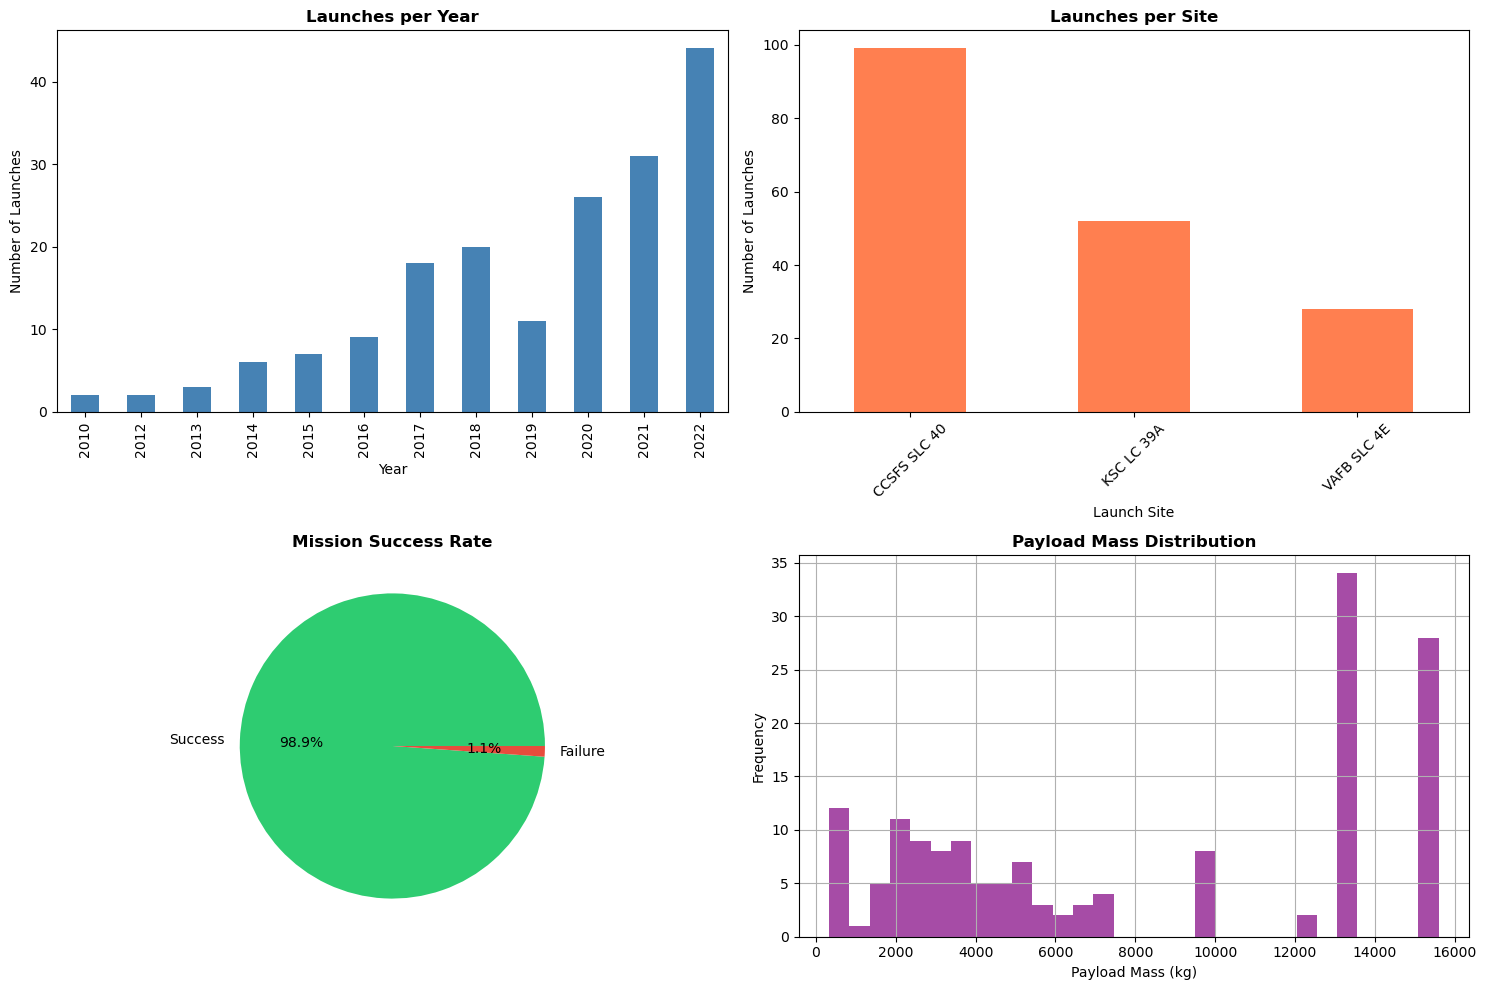


✓ Summary visualization saved!


In [1]:
# Cell 1: Install and Import Libraries
!pip install requests pandas numpy

import requests
import pandas as pd
from pandas import json_normalize
import numpy as np

# Cell 2: Define API URL and Make Request
# SpaceX API endpoint for past launches
spacex_url = "https://api.spacexdata.com/v4/launches/past"

# Make GET request
response = requests.get(spacex_url)
print(f"Status Code: {response.status_code}")

# Check if request was successful
if response.status_code == 200:
    print("✓ Data fetched successfully!")
else:
    print("✗ Failed to fetch data")

# Cell 3: Parse JSON Response
# Convert JSON response to Python dictionary
data = response.json()
print(f"Total launches retrieved: {len(data)}")
print(f"\nFirst launch data structure:")
print(list(data[0].keys()))

# Cell 4: Normalize JSON to DataFrame
# Flatten nested JSON structure
df = json_normalize(data)
print(f"DataFrame shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

# Cell 5: Get Rocket Information
# Fetch rocket details
rockets_url = "https://api.spacexdata.com/v4/rockets"
rockets_response = requests.get(rockets_url)
rockets_data = rockets_response.json()

# Create rockets dataframe
rockets_df = json_normalize(rockets_data)
print(f"Total rockets: {len(rockets_df)}")
rockets_df[['name', 'type', 'active']].head()

# Cell 6: Get Launchpad Information
# Fetch launchpad details
launchpads_url = "https://api.spacexdata.com/v4/launchpads"
launchpads_response = requests.get(launchpads_url)
launchpads_data = launchpads_response.json()

# Create launchpads dataframe
launchpads_df = json_normalize(launchpads_data)
print(f"Total launchpads: {len(launchpads_df)}")
launchpads_df[['name', 'full_name', 'locality', 'region']].head()

# Cell 7: Get Payload Information
# Fetch payload details
payloads_url = "https://api.spacexdata.com/v4/payloads"
payloads_response = requests.get(payloads_url)
payloads_data = payloads_response.json()

# Create payloads dataframe
payloads_df = json_normalize(payloads_data)
print(f"Total payloads: {len(payloads_df)}")
payloads_df.head()

# Cell 8: Get Core Information (Boosters)
# Fetch core/booster details
cores_url = "https://api.spacexdata.com/v4/cores"
cores_response = requests.get(cores_url)
cores_data = cores_response.json()

# Create cores dataframe
cores_df = json_normalize(cores_data)
print(f"Total cores: {len(cores_df)}")
cores_df.head()

# Cell 9: Extract Key Features from Launch Data
# Select important columns
launch_features = df[[
    'flight_number',
    'name',
    'date_utc',
    'rocket',
    'success',
    'failures',
    'launchpad',
    'payloads',
    'cores'
]]

print(f"Selected features shape: {launch_features.shape}")
launch_features.head()

# Cell 10: Clean Date Column
# Convert date to datetime
launch_features['date_utc'] = pd.to_datetime(launch_features['date_utc'])
launch_features['year'] = launch_features['date_utc'].dt.year
launch_features['month'] = launch_features['date_utc'].dt.month

print("Date columns added:")
launch_features[['name', 'date_utc', 'year', 'month']].head()

# Cell 11: Handle Nested Columns
# Extract first payload ID (most launches have single payload)
launch_features['payload_id'] = launch_features['payloads'].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None
)

# Extract first core ID
launch_features['core_id'] = launch_features['cores'].apply(
    lambda x: x[0]['core'] if isinstance(x, list) and len(x) > 0 else None
)

# Extract landing outcome
launch_features['landing_outcome'] = launch_features['cores'].apply(
    lambda x: x[0].get('landing_type', None) if isinstance(x, list) and len(x) > 0 else None
)

print("Extracted nested data:")
launch_features[['name', 'payload_id', 'core_id', 'landing_outcome']].head()

# Cell 12: Merge with Rocket Data
# Create rocket lookup dictionary
rocket_dict = rockets_df.set_index('id')['name'].to_dict()

# Map rocket IDs to names
launch_features['rocket_name'] = launch_features['rocket'].map(rocket_dict)

print("Rocket names added:")
launch_features[['name', 'rocket_name']].head()

# Cell 13: Merge with Launchpad Data
# Create launchpad lookup dictionary
launchpad_dict = launchpads_df.set_index('id')['name'].to_dict()

# Map launchpad IDs to names
launch_features['launch_site'] = launch_features['launchpad'].map(launchpad_dict)

print("Launch sites added:")
launch_features[['name', 'launch_site']].head()

# Cell 14: Merge with Payload Data
# Create payload lookup dictionary
payload_mass_dict = payloads_df.set_index('id')['mass_kg'].to_dict()
payload_orbit_dict = payloads_df.set_index('id')['orbit'].to_dict()

# Map payload information
launch_features['payload_mass_kg'] = launch_features['payload_id'].map(payload_mass_dict)
launch_features['orbit'] = launch_features['payload_id'].map(payload_orbit_dict)

print("Payload information added:")
launch_features[['name', 'payload_mass_kg', 'orbit']].head()

# Cell 15: Filter for Falcon 9 Launches Only
# Keep only Falcon 9 launches
falcon9_df = launch_features[launch_features['rocket_name'] == 'Falcon 9'].copy()

print(f"Total Falcon 9 launches: {len(falcon9_df)}")
print(f"Date range: {falcon9_df['date_utc'].min()} to {falcon9_df['date_utc'].max()}")

# Cell 16: Create Clean Dataset
# Select final columns
final_df = falcon9_df[[
    'flight_number',
    'name',
    'date_utc',
    'year',
    'month',
    'rocket_name',
    'launch_site',
    'payload_mass_kg',
    'orbit',
    'success',
    'landing_outcome'
]].copy()

# Rename columns for clarity
final_df.columns = [
    'FlightNumber',
    'Mission',
    'Date',
    'Year',
    'Month',
    'Rocket',
    'LaunchSite',
    'PayloadMass',
    'Orbit',
    'MissionOutcome',
    'LandingOutcome'
]

print("Final dataset shape:", final_df.shape)
final_df.head(10)

# Cell 17: Basic Statistics
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Total Falcon 9 Launches: {len(final_df)}")
print(f"Date Range: {final_df['Date'].min().date()} to {final_df['Date'].max().date()}")
print(f"Unique Launch Sites: {final_df['LaunchSite'].nunique()}")
print(f"Unique Orbits: {final_df['Orbit'].nunique()}")
print(f"\nMission Success Rate: {final_df['MissionOutcome'].mean()*100:.2f}%")
print(f"Average Payload Mass: {final_df['PayloadMass'].mean():.2f} kg")

# Cell 18: Check Data Quality
print("\nData Quality Check:")
print("-" * 60)
print("Missing values per column:")
print(final_df.isnull().sum())
print("\nData types:")
print(final_df.dtypes)

# Cell 19: Save to CSV
# Save cleaned data

import os

#  Create 'data' folder if it doesn't exist
os.makedirs('data', exist_ok=True)

# Save cleaned data
final_df.to_csv('data/spacex_launch_data.csv', index=False)
print(" Data saved to 'data/spacex_launch_data.csv'")

# Cell 20: Summary Visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Launches per year
final_df['Year'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Launches per Year', fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Number of Launches')

# Launches per site
final_df['LaunchSite'].value_counts().plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Launches per Site', fontweight='bold')
axes[0, 1].set_xlabel('Launch Site')
axes[0, 1].set_ylabel('Number of Launches')
axes[0, 1].tick_params(axis='x', rotation=45)

# Success rate
success_counts = final_df['MissionOutcome'].value_counts()
axes[1, 0].pie(success_counts, labels=['Success', 'Failure'], autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('Mission Success Rate', fontweight='bold')

# Payload distribution
final_df['PayloadMass'].hist(bins=30, ax=axes[1, 1], color='purple', alpha=0.7)
axes[1, 1].set_title('Payload Mass Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Payload Mass (kg)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('api_data_collection_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Summary visualization saved!")